<a href="https://colab.research.google.com/github/rodwol/hidden_markov_models/blob/main/Hidden_Markov_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install hmmlearn

import the necessary libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt

from hmmlearn import hmm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# download the dataset
path = kagglehub.dataset_download("rodasgoniche/data-new")

print("Dataset path:", path)
print("Files in root directory:")
print(os.listdir(path))


Using Colab cache for faster access to the 'data-new' dataset.
Dataset path: /kaggle/input/data-new
Files in root directory:
['Standing_7-2026-03-05_21-13-15', 'Jumping_10-2026-03-05_21-05-34', 'Standing_6-2026-03-05_21-12-51', 'Still_5-2026-03-05_22-06-41', 'Jumping_4-2026-03-05_21-02-37', 'Jumping_2-2026-03-05_21-01-46', 'Jumping_9-2026-03-05_21-04-56', 'Walking_1-2026-03-05_21-41-53', 'Walking_5-2026-03-05_21-43-00', 'Walking_7-2026-03-05_21-43-35', 'Still_4-2026-03-05_22-06-24', 'Walking_9-2026-03-05_21-44-14', 'Still_6-2026-03-05_22-06-58', 'Jumping_7-2026-03-05_21-03-55', 'Jumping_3-2026-03-05_21-02-05', 'Jumping_1-2026-03-05_21-01-11', 'Walking_8-2026-03-05_21-43-51', 'Still_3-2026-03-05_22-06-08', 'Still_1-2026-03-05_22-05-32', 'Standing_5-2026-03-05_21-12-13', 'Walking_4-2026-03-05_21-42-44', 'Jumping_8-2026-03-05_21-04-31', 'Walking_2-2026-03-05_21-42-10', 'Still_7-2026-03-05_22-07-14', 'Standing_1-2026-03-05_21-10-56', 'Still_8-2026-03-05_22-07-34', 'Standing_10-2026-03-05_2

In [ ]:
path = "/root/.cache/kagglehub/datasets/rodasgoniche/data-new/versions/1"
all_data = []

for folder in os.listdir(path):
  folder_path = os.path.join(path, folder)
  if os.path.isdir(folder_path):
    # extract activity from folder name
    activity = folder.split("_")[0].lower()

    for file in os.listdir(folder_path):
      file_path = os.path.join(folder_path, file)
      try:
        df = pd.read_csv(file_path)
        # skip empty dataframes
        if df.empty:
          print(f"Skipping empty dataframe in {file_path}")
          continue

        df["activity"] = activity
        df["sensor"] = file.replace(".csv", "")
        df["session"] = folder
        all_data.append(df)

      except pd.errors.EmptyDataError:
        print(f"Skipping empty dataframe in {file_path}")

dataset = pd.concat(all_data, ignore_index=True)
print("Final dataset shape:", dataset.shape)
dataset.head()

Skipping empty dataframe in /root/.cache/kagglehub/datasets/rodasgoniche/data-new/versions/1/Still_6-2026-03-05_22-06-58/AccelerometerUncalibrated.csv
Skipping empty dataframe in /root/.cache/kagglehub/datasets/rodasgoniche/data-new/versions/1/Still_6-2026-03-05_22-06-58/Annotation.csv
Skipping empty dataframe in /root/.cache/kagglehub/datasets/rodasgoniche/data-new/versions/1/Still_10-2026-03-05_22-08-07/AccelerometerUncalibrated.csv
Skipping empty dataframe in /root/.cache/kagglehub/datasets/rodasgoniche/data-new/versions/1/Still_10-2026-03-05_22-08-07/Annotation.csv
Skipping empty dataframe in /root/.cache/kagglehub/datasets/rodasgoniche/data-new/versions/1/Walking_6-2026-03-05_21-43-18/AccelerometerUncalibrated.csv
Skipping empty dataframe in /root/.cache/kagglehub/datasets/rodasgoniche/data-new/versions/1/Walking_6-2026-03-05_21-43-18/Annotation.csv
Skipping empty dataframe in /root/.cache/kagglehub/datasets/rodasgoniche/data-new/versions/1/Jumping_6-2026-03-05_21-03-27/Accelerome

,time,seconds_elapsed,z,y,x,activity,sensor,session,version,device name,recording epoch time,recording time,recording timezone,platform,appVersion,device id,sensors,sampleRateMs,standardisation,platform version
0,1.772748e+18,0.234328,9.768343,-0.095768,0.050278,still,TotalAcceleration,Still_6-2026-03-05_22-06-58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.772748e+18,0.250288,9.749189,-0.086191,0.045490,still,TotalAcceleration,Still_6-2026-03-05_22-06-58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.772748e+18,0.266249,9.753978,-0.098162,0.052672,still,TotalAcceleration,Still_6-2026-03-05_22-06-58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.772748e+18,0.282210,9.753978,-0.081403,0.057461,still,TotalAcceleration,Still_6-2026-03-05_22-06-58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.772748e+18,0.298201,9.730036,-0.102951,0.059855,still,TotalAcceleration,Still_6-2026-03-05_22-06-58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


timestamp cleaning

In [ ]:
acc_data = dataset[dataset["sensor"] == "Accelerometer"]
gyro_data = dataset[dataset["sensor"] == "Gyroscope"]

In [ ]:
acc_data = acc_data.rename(columns={
    "x":"acc_x",
    "y":"acc_y",
    "z":"acc_z"
})

gyro_data = gyro_data.rename(columns={
    "x":"gyro_x",
    "y":"gyro_y",
    "z":"gyro_z"
})

In [ ]:
acc_data = acc_data.sort_values("time")
gyro_data = gyro_data.sort_values("time")

# Convert 'time' columns to datetime objects for merge_asof with Timedelta tolerance
acc_data["time"] = pd.to_datetime(acc_data["time"])
gyro_data["time"] = pd.to_datetime(gyro_data["time"])

dataset = pd.merge_asof(
    acc_data,
    gyro_data,
    on="time",
    by="session",
    direction="nearest",
    tolerance=pd.Timedelta("20ms")
)

In [ ]:
print(dataset.columns)

Index(['time', 'seconds_elapsed_x', 'acc_z', 'acc_y', 'acc_x', 'activity_x',
       'sensor_x', 'session', 'version_x', 'device name_x',
       'recording epoch time_x', 'recording time_x', 'recording timezone_x',
       'platform_x', 'appVersion_x', 'device id_x', 'sensors_x',
       'sampleRateMs_x', 'standardisation_x', 'platform version_x',
       'seconds_elapsed_y', 'gyro_z', 'gyro_y', 'gyro_x', 'activity_y',
       'sensor_y', 'version_y', 'device name_y', 'recording epoch time_y',
       'recording time_y', 'recording timezone_y', 'platform_y',
       'appVersion_y', 'device id_y', 'sensors_y', 'sampleRateMs_y',
       'standardisation_y', 'platform version_y'],
      dtype='object')


In [ ]:
print("Accelerometer rows:", acc_data.shape)
print("Gyroscope rows:", gyro_data.shape)

Accelerometer rows: (36135, 20)
Gyroscope rows: (36144, 20)


In [ ]:
# remove duplicated, focusing on the 'time' column to ensure unique timestamps
dataset = dataset.drop_duplicates(subset=["session","time"])
# sort by time
dataset = dataset.sort_values(["session","time"])
dataset = dataset.dropna(axis=1, how="all")

# convert timestamp to datetime
dataset["time"] = pd.to_datetime(dataset["time"])

dataset = dataset
for session in dataset["session"].unique():
  session_data = dataset[dataset["session"] == session]
  assert np.all(np.diff(session_data["time"].astype("int64")) > 0)


print("Timestamp cleaning done.")
print(dataset.columns)

Timestamp cleaning done.
Index(['time', 'seconds_elapsed_x', 'acc_z', 'acc_y', 'acc_x', 'activity_x',
       'sensor_x', 'session', 'seconds_elapsed_y', 'gyro_z', 'gyro_y',
       'gyro_x', 'activity_y', 'sensor_y'],
      dtype='object')


In [ ]:
dataset = dataset[[
    "time",
    "seconds_elapsed_x", # Using _x for elapsed time

    "acc_x","acc_y","acc_z",           # accelerometer
    "gyro_x","gyro_y","gyro_z",   # gyroscope

    "activity_x", # Using _x for activity
    "session"
]]
dataset = dataset.rename(columns={
    "seconds_elapsed_x": "seconds_elapsed",
    "activity_x": "activity"
})


In [ ]:
dataset = dataset.dropna()

In [ ]:
print(dataset.isnull().sum())

time               0
seconds_elapsed    0
acc_x              0
acc_y              0
acc_z              0
gyro_x             0
gyro_y             0
gyro_z             0
activity           0
session            0
dtype: int64


In [ ]:
print(dataset["activity"].value_counts())

activity
still       9465
standing    9201
walking     9131
jumping     8338
Name: count, dtype: int64


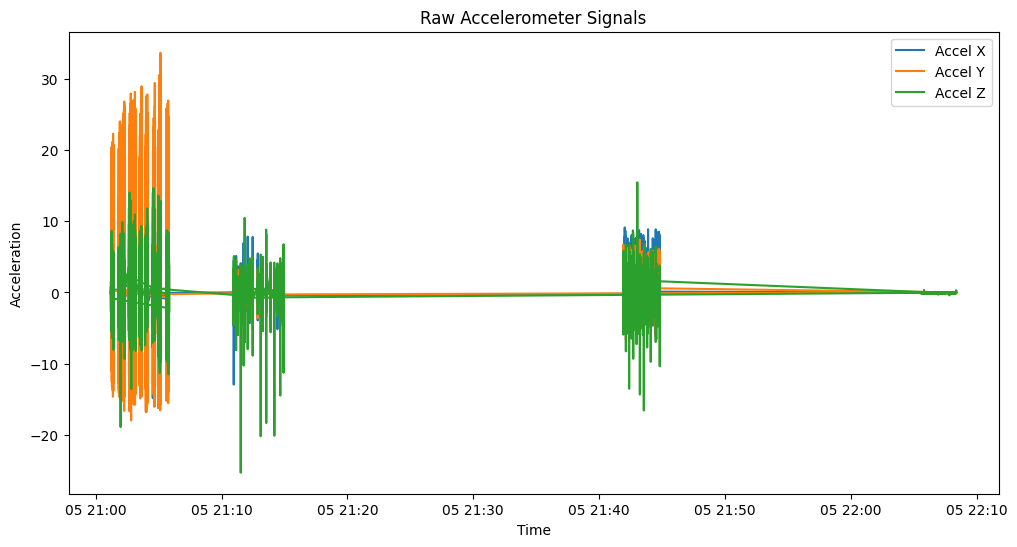

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(dataset["time"], dataset["acc_x"], label="Accel X")
plt.plot(dataset["time"], dataset["acc_y"], label="Accel Y")
plt.plot(dataset["time"], dataset["acc_z"], label="Accel Z")

plt.title("Raw Accelerometer Signals")
plt.xlabel("Time")
plt.ylabel("Acceleration")
plt.legend()
plt.show()

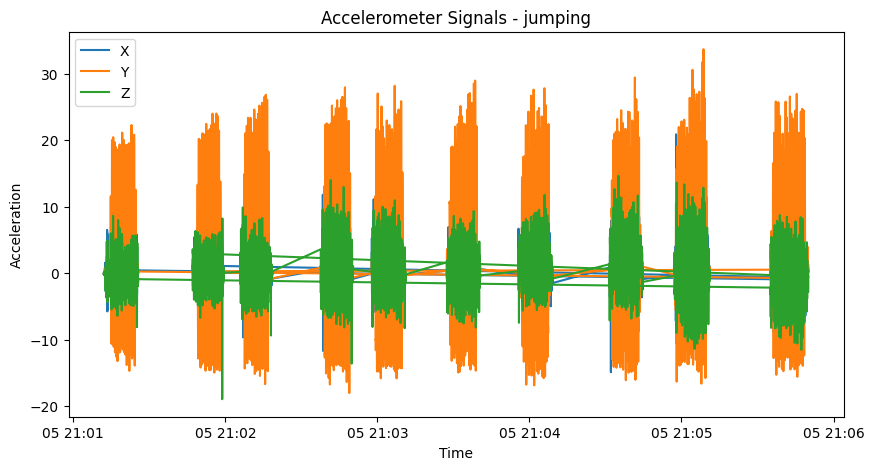

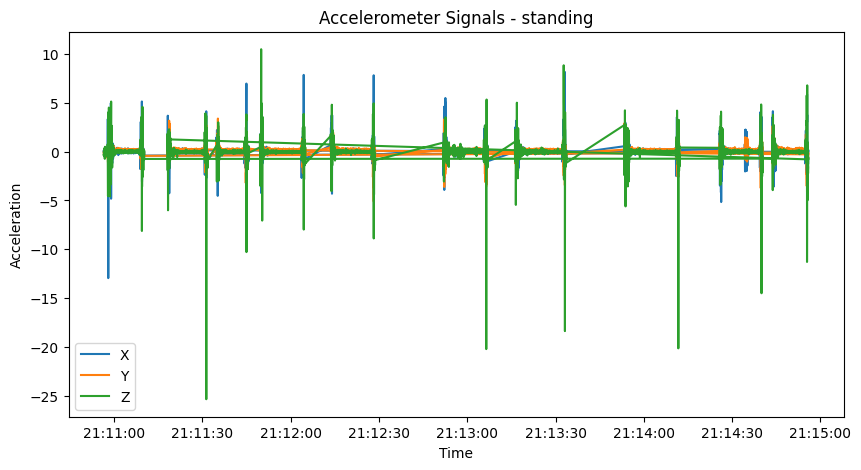

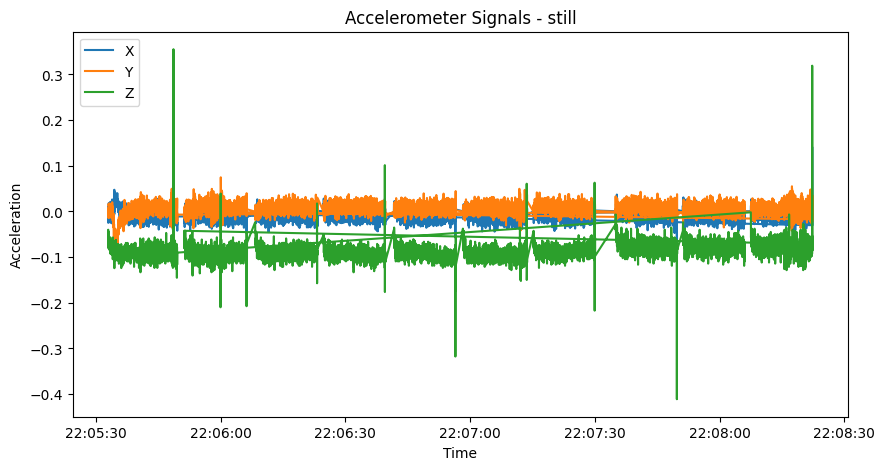

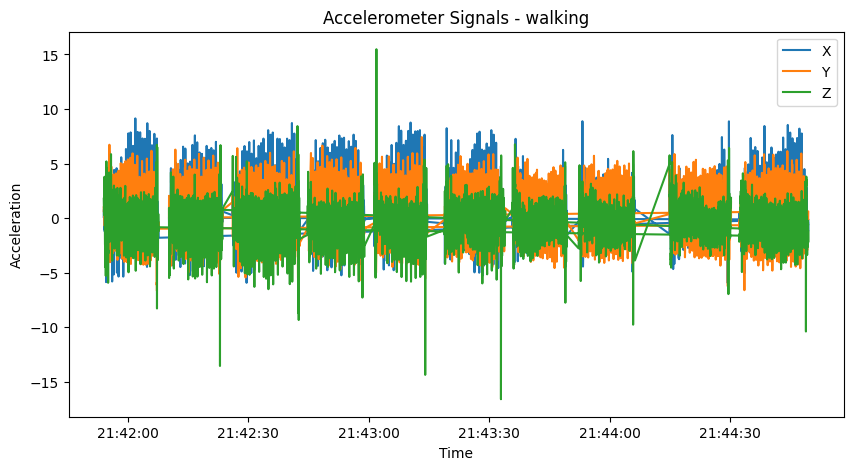

In [ ]:
activities = dataset["activity"].unique()

for activity in activities:
    data = dataset[dataset["activity"] == activity]

    plt.figure(figsize=(10,5))
    plt.plot(data["time"], data["acc_x"], label="X")
    plt.plot(data["time"], data["acc_y"], label="Y")
    plt.plot(data["time"], data["acc_z"], label="Z")

    plt.title(f"Accelerometer Signals - {activity}")
    plt.xlabel("Time")
    plt.ylabel("Acceleration")
    plt.legend()
    plt.show()

compute sampling rate

In [ ]:
dt = np.diff(dataset["time"].astype("int64") / 1e9)
sampling_rate = 1/np.mean(dt)

print("Estimated sampling rate:", sampling_rate)

Estimated sampling rate: 13.907463210840483


#**Resampling**
The accelerometer data was recorded using a smartphone sensor. Because different devices may record data at slightly different frequencies, we estimated the sampling rate by computing the time difference between consecutive timestamps. The average sampling rate was approximately X Hz.
To ensure consistency in the dataset, the signals were resampled to 50 Hz, meaning one sample every 20 ms.

In [ ]:
dataset = dataset.set_index("time")

dataset_resampled = (
    dataset
    .groupby("session")[
        [
            "acc_x","acc_y","acc_z",
            "gyro_x","gyro_y","gyro_z"
        ]
    ]
    .resample("20ms")
    .mean()
)

dataset_resampled = dataset_resampled.interpolate()

dataset_resampled.reset_index(inplace=True)
dataset_resampled.head()

,session,time,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z
0,Jumping_1-2026-03-05_21-01-11,2026-03-05 21:01:11.980,-0.106335,-0.040114,-0.108611,-0.600481,0.072082,-0.048869
1,Jumping_1-2026-03-05_21-01-11,2026-03-05 21:01:12.000,-0.060490,-0.012023,0.014507,-0.600481,0.072082,-0.048869
2,Jumping_1-2026-03-05_21-01-11,2026-03-05 21:01:12.020,0.039805,0.026529,0.011224,-0.600481,0.072082,-0.048869
3,Jumping_1-2026-03-05_21-01-11,2026-03-05 21:01:12.040,0.077699,0.115350,-0.122824,-0.600481,0.072082,-0.048869
4,Jumping_1-2026-03-05_21-01-11,2026-03-05 21:01:12.060,-0.078846,0.116791,-0.114249,-0.600481,0.072082,-0.048869


calclate and plot the magnitude of acceleration from 3-axis accelerometer data

In [ ]:
session_activity_map = (
    dataset
    .reset_index()
    .drop_duplicates(subset=["session"])
    [["session","activity"]]
    .set_index("session")["activity"]
)

dataset_resampled["activity"] = dataset_resampled["session"].map(session_activity_map)

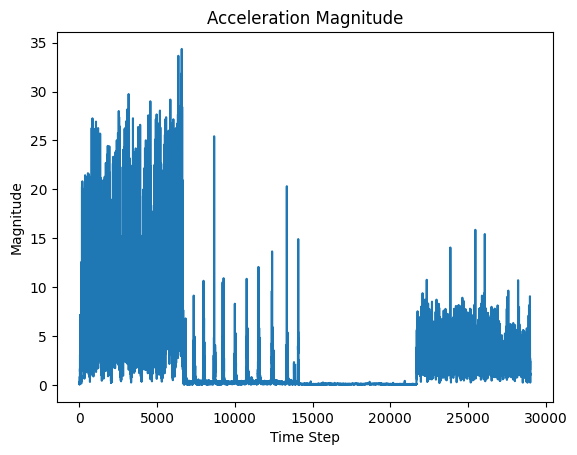

In [ ]:
dataset_resampled["acc_mag"] = np.sqrt(
    dataset_resampled["acc_x"]**2 +
    dataset_resampled["acc_y"]**2 +
    dataset_resampled["acc_z"]**2
)

magnitude = dataset_resampled["acc_mag"]

plt.plot(magnitude)
plt.title("Acceleration Magnitude")
plt.xlabel("Time Step")
plt.ylabel("Magnitude")
plt.show()

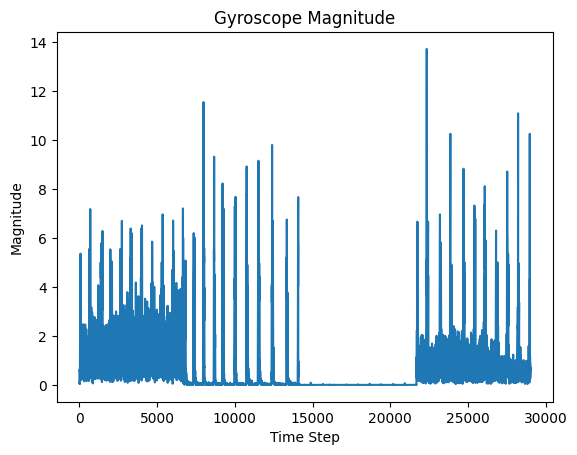

In [ ]:
dataset_resampled["gyro_mag"] = np.sqrt(
    dataset_resampled["gyro_x"]**2 +
    dataset_resampled["gyro_y"]**2 +
    dataset_resampled["gyro_z"]**2
)

gyro_magnitude = dataset_resampled["gyro_mag"]

plt.plot(gyro_magnitude)
plt.title("Gyroscope Magnitude")
plt.xlabel("Time Step")
plt.ylabel("Magnitude")
plt.show()

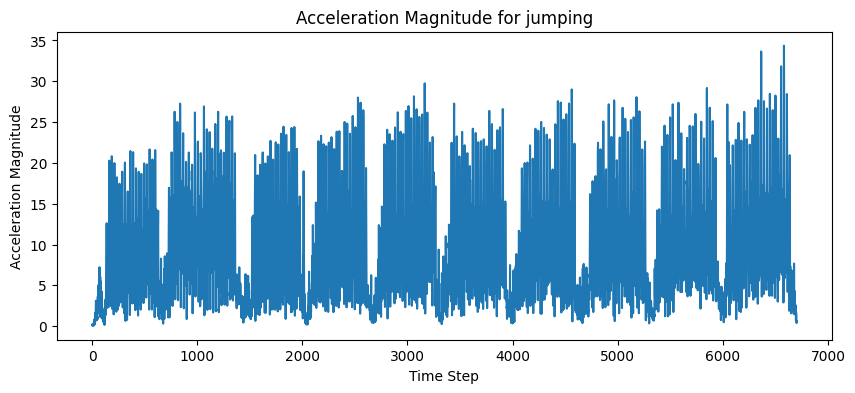

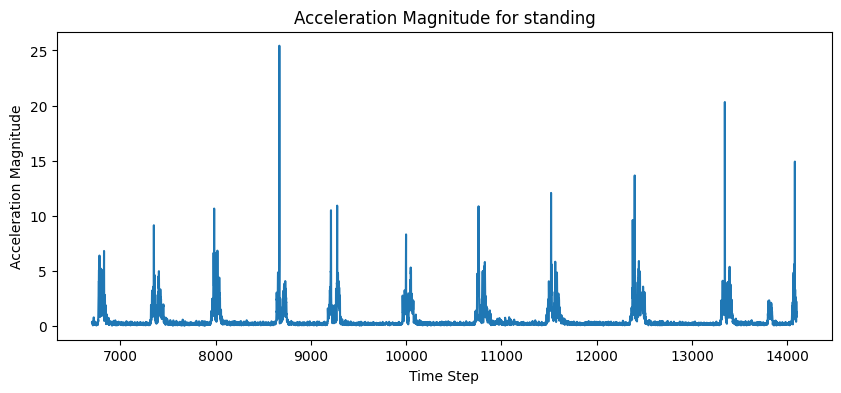

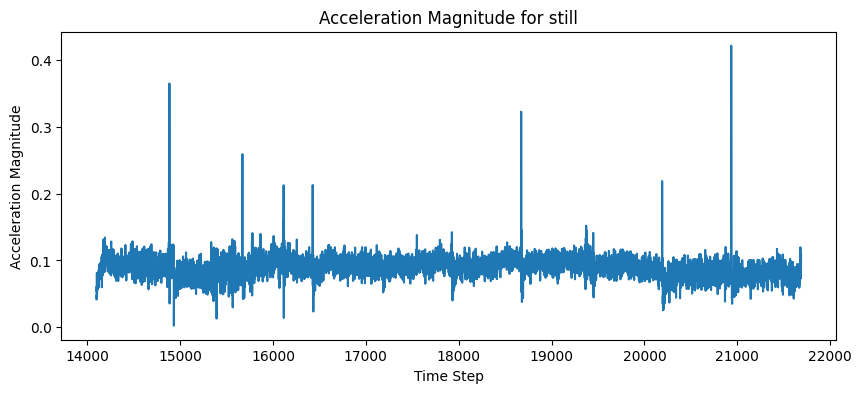

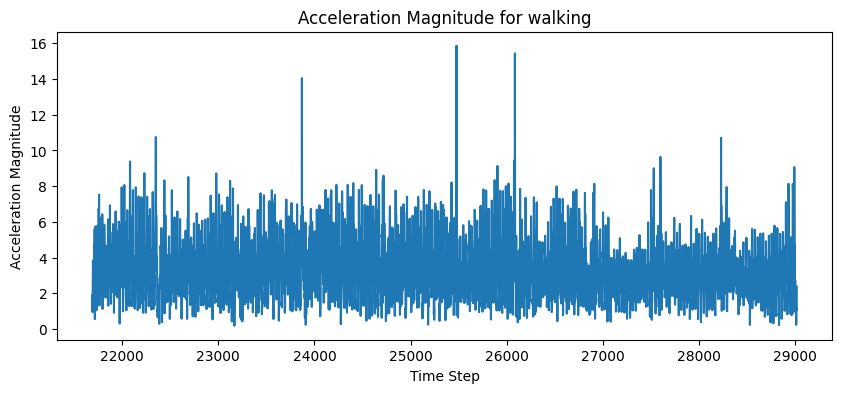

In [ ]:
for activity in dataset_resampled["activity"].unique():

    subset_resampled = dataset_resampled[
        dataset_resampled["activity"] == activity
    ]

    plt.figure(figsize=(10,4))

    plt.plot(subset_resampled["acc_mag"])

    plt.title(f"Acceleration Magnitude for {activity}")
    plt.xlabel("Time Step")
    plt.ylabel("Acceleration Magnitude")

    plt.show()

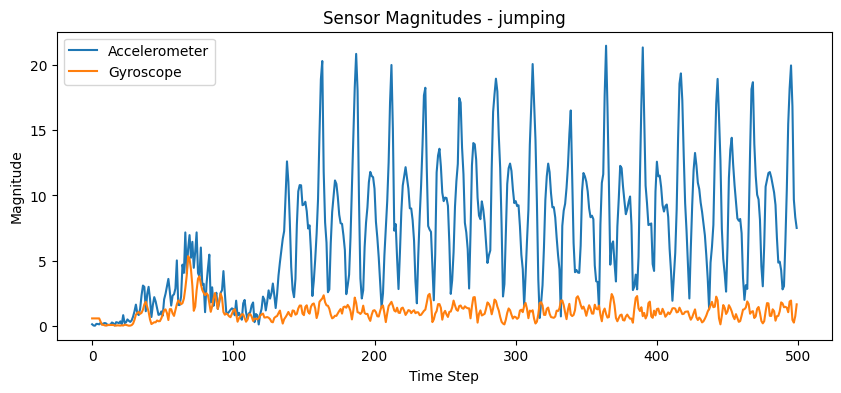

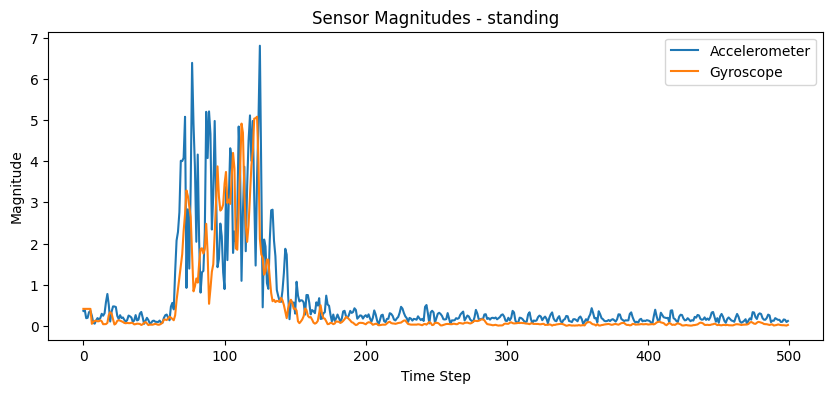

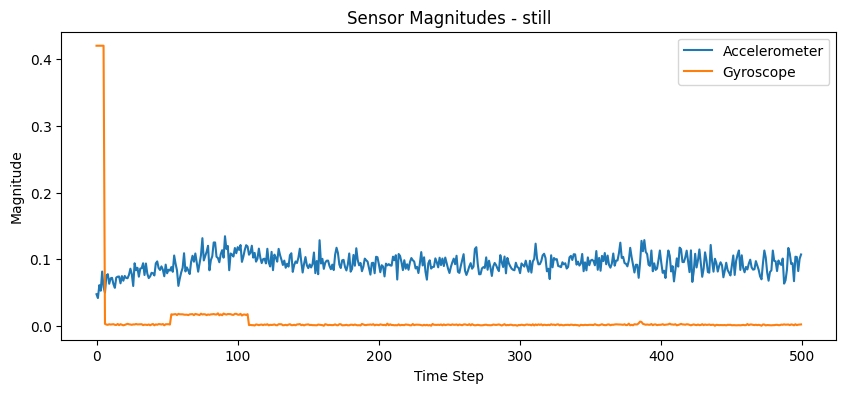

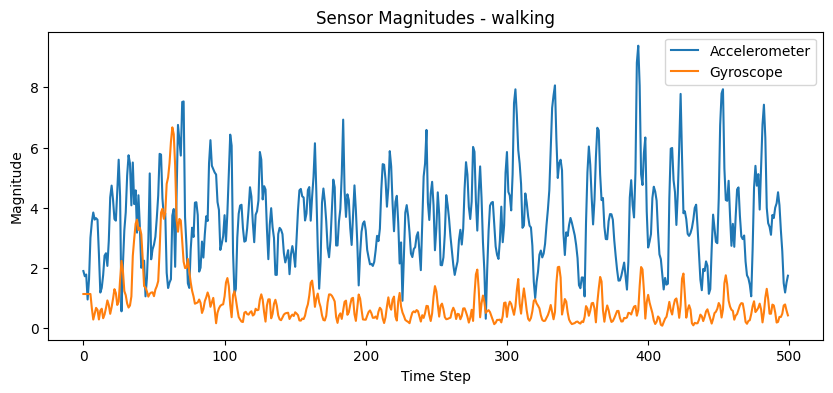

In [ ]:
for activity in dataset_resampled["activity"].unique():

    subset = dataset_resampled[
        dataset_resampled["activity"] == activity
    ]

    plt.figure(figsize=(10,4))

    plt.plot(subset["acc_mag"].values[:500], label="Accelerometer")
    plt.plot(subset["gyro_mag"].values[:500], label="Gyroscope")

    plt.title(f"Sensor Magnitudes - {activity}")
    plt.xlabel("Time Step")
    plt.ylabel("Magnitude")
    plt.legend()

    plt.show()

applying low-pass filter to smooth the acceleration magnitude by removing high-frequency noise while preserving the meaningful movement patterns.

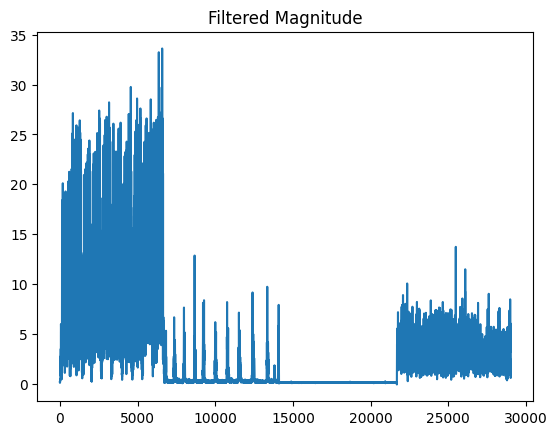

In [ ]:
def lowpass_filter(signal, cutoff=10, fs=50, order=4):
  nyq = 0.5 * fs
  normal_cutoff = cutoff / nyq
  b, a = butter(order, normal_cutoff, btype='low')
  return filtfilt(b, a, signal)

magnitude_filtered = lowpass_filter(magnitude, cutoff=10, fs=50)

plt.plot(magnitude_filtered)
plt.title("Filtered Magnitude")
plt.show()

# Windowing
To extract meaningful features from the continuous sensor signals, the data was divided into fixed-length time windows.
Given the sampling rate of 50 Hz, a window size of 2 seconds (100 samples) was chosen.
This window length captures several motion cycles during walking while still allowing quick detection of activity transitions.

The window size was selected based on the sampling rate of the sensor data. After resampling, the data had an effective sampling rate of approximately 50 Hz.

A window size of 100 samples was therefore chosen, corresponding to 2 seconds of motion data. This duration is sufficient to capture meaningful motion patterns such as steps during walking or repeated impulses during jumping.

A 50% overlap (step size = 50 samples) was used to improve temporal resolution and increase the number of training examples while maintaining continuity between windows.

In [ ]:
window_size = 100
step_size = 50

features = []

# Update axes to reflect the actual column names in dataset_resampled
axes = [
    "acc_x", "acc_y", "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "acc_mag", "gyro_mag"
]

for start in range(0, len(dataset_resampled) - window_size, step_size):
    window = dataset_resampled.iloc[start:start+window_size]

    window_activity = window["activity"].mode()[0]
    if (window["activity"] == window_activity).mean() < 0.8:
      continue

    feature_row = {}

    for axis in axes:
      signal = window[axis].values

      # time-domain fetures
      feature_row[f"{axis}_mean"] = signal.mean()
      feature_row[f"{axis}_std"] = signal.std()
      feature_row[f"{axis}_max"] = signal.max()
      feature_row[f"{axis}_min"] = signal.min()
      feature_row[f"{axis}_range"] = signal.max() - signal.min()
      feature_row[f"{axis}_median"] = np.median(signal)
      feature_row[f"{axis}_iqr"] = np.quantile(signal, 0.75) - np.quantile(signal, 0.25)
      feature_row[f"{axis}_rms"] = np.sqrt(np.mean(signal**2))
      feature_row[f"{axis}_sma"] = np.sum(np.abs(signal)) / len(signal)

      fft_vals = np.fft.rfft(signal)
      fft_freq = np.fft.rfftfreq(len(signal), d=1/50)  # 50 Hz sampling
      feature_row[f"{axis}_dominant_freq"] = fft_freq[np.argmax(np.abs(fft_vals))]
      feature_row[f"{axis}_spectral_energy"] = np.sum(np.abs(fft_vals)**2)

    feature_row["activity"] = window_activity
    feature_row["session"] = window["session"].iloc[0]  # optional, useful for sequence split

    features.append(feature_row)

features_df = pd.DataFrame(features)
features_df.head()

,acc_x_mean,acc_x_std,acc_x_max,acc_x_min,acc_x_range,acc_x_median,acc_x_iqr,acc_x_rms,acc_x_sma,acc_x_dominant_freq,...,gyro_mag_min,gyro_mag_range,gyro_mag_median,gyro_mag_iqr,gyro_mag_rms,gyro_mag_sma,gyro_mag_dominant_freq,gyro_mag_spectral_energy,activity,session
0,0.086515,2.099215,6.535832,-5.418606,11.954438,0.001358,1.414058,2.100997,1.412360,1.0,...,0.047841,5.317474,0.965556,1.509609,1.691972,1.229790,0.0,21876.113308,jumping,Jumping_1-2026-03-05_21-01-11
1,-0.114078,2.131218,6.535832,-5.418606,11.954438,-0.141130,2.196213,2.134269,1.538814,1.0,...,0.212111,5.153204,0.998941,1.027944,1.740320,1.409166,0.0,25072.410375,jumping,Jumping_1-2026-03-05_21-01-11
2,-0.576871,1.431047,2.386397,-6.241717,8.628114,-0.412406,1.672716,1.542944,1.115049,0.0,...,0.212111,2.160461,0.952238,0.647477,1.129117,1.036006,0.0,11741.199975,jumping,Jumping_1-2026-03-05_21-01-11
3,-0.704991,1.700462,3.727513,-6.241717,9.969230,-0.799440,2.047980,1.840811,1.466363,0.0,...,0.325362,2.155867,1.173259,0.548279,1.317793,1.241414,0.0,16388.437224,jumping,Jumping_1-2026-03-05_21-01-11
4,-0.682405,1.992050,4.601316,-4.700495,9.301811,-1.063812,2.618555,2.105692,1.748995,0.0,...,0.147411,2.333818,1.195824,0.523939,1.297089,1.212595,0.0,15764.149240,jumping,Jumping_1-2026-03-05_21-01-11


In [ ]:
acc_mag = window["acc_mag"]
feature_row = {
    "mean": acc_mag.mean(),
    "std": acc_mag.std(),
    "max": acc_mag.max(),
    "activity": window["activity"].mode()[0]
}
list(feature_row.items())[:5]

[('mean', np.float64(3.5928210411301404)),
 ('std', 1.8149832136705546),
 ('max', 9.06593276198143),
 ('activity', 'walking')]

normalizing features

In [ ]:
train_sessions = []
test_sessions = []

for activity in features_df["activity"].unique():

    activity_sessions = features_df[
        features_df["activity"] == activity
    ]["session"].unique()

    np.random.shuffle(activity_sessions)

    split_index = int(0.8 * len(activity_sessions))

    train_sessions.extend(activity_sessions[:split_index])
    test_sessions.extend(activity_sessions[split_index:])

train_data = features_df[features_df["session"].isin(train_sessions)]
test_data = features_df[features_df["session"].isin(test_sessions)]

X_train = train_data.drop(["activity","session"], axis=1)
y_train = train_data["activity"]

X_test = test_data.drop(["activity","session"], axis=1)
y_test = test_data["activity"]

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model training

In [ ]:
activity_models = {}

for activity in train_data["activity"].unique():

    activity_features = X_train[y_train == activity]

    if len(activity_features) < 10:
        print(f"Skipping {activity} (not enough samples)")
        continue

    model = hmm.GaussianHMM(
        n_components=2,
        covariance_type="diag",
        n_iter=200,
        tol=1e-4,
        random_state=42,
        min_covar=0.001
    )

    model.fit(activity_features)

    log_likelihood = model.score(activity_features)

    print(f"{activity} model trained")
    print(f"Log Likelihood: {log_likelihood:.2f}\n")

    activity_models[activity] = model

jumping model trained
Log Likelihood: -5578.14

standing model trained
Log Likelihood: 14056.64

still model trained
Log Likelihood: 34449.50

walking model trained
Log Likelihood: 1984.80



In [ ]:
predictions = []
true_labels = []

for session in test_data["session"].unique():

    session_data = test_data[test_data["session"] == session]

    X_seq = scaler.transform(
        session_data.drop(["activity","session"], axis=1)
    )

    scores = {}

    for activity, model in activity_models.items():

        # compute likelihood of entire sequence
        scores[activity] = model.score(X_seq)

    predicted_activity = max(scores, key=scores.get)

    predictions.extend([predicted_activity] * len(session_data))
    true_labels.extend(session_data["activity"])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Overall metrics
print("Accuracy:", accuracy_score(y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, predictions))

# Detailed metrics
report = classification_report(y_test, predictions, output_dict=True)

print("\nPer-Activity Metrics:")
for activity in sorted(y_test.unique()):

    sensitivity = report[activity]["recall"]
    precision = report[activity]["precision"]
    f1 = report[activity]["f1-score"]

    print(f"{activity}: Sensitivity={sensitivity:.2f}, Precision={precision:.2f}, F1={f1:.2f}")

Accuracy: 0.8809523809523809
Confusion Matrix:
 [[26  0  0  0]
 [ 0 40  0  0]
 [ 0 15 15  0]
 [ 0  0  0 30]]

Per-Activity Metrics:
jumping: Sensitivity=1.00, Precision=1.00, F1=1.00
standing: Sensitivity=1.00, Precision=0.73, F1=0.84
still: Sensitivity=0.50, Precision=1.00, F1=0.67
walking: Sensitivity=1.00, Precision=1.00, F1=1.00


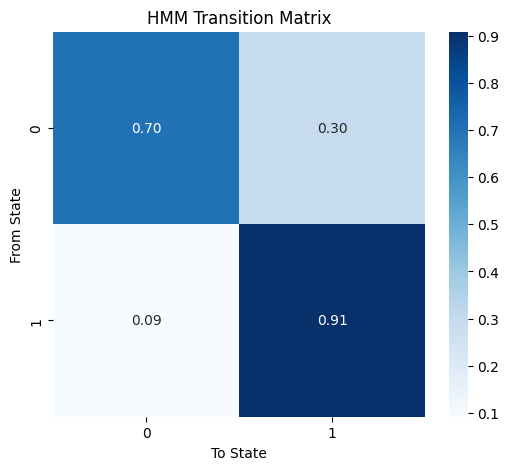

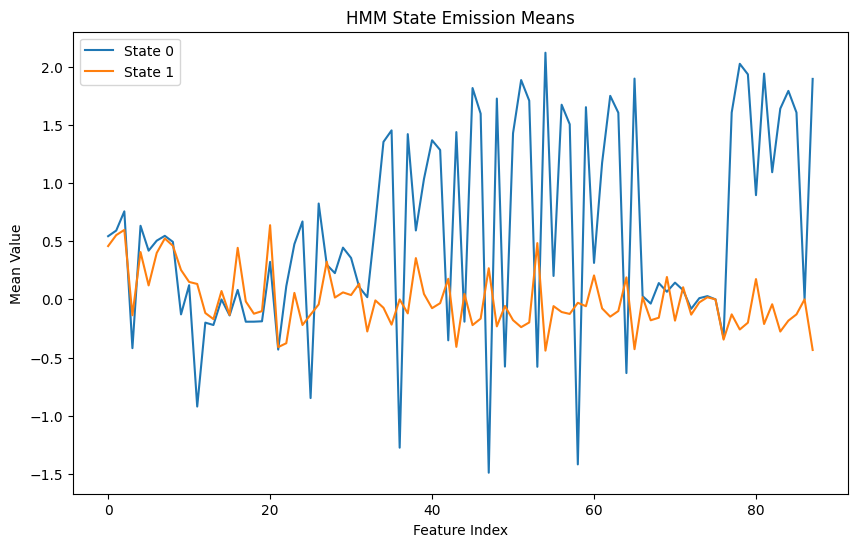

In [ ]:
import seaborn as sns

# Transition matrix
plt.figure(figsize=(6,5))
sns.heatmap(model.transmat_, annot=True, cmap="Blues", fmt=".2f")
plt.title("HMM Transition Matrix")
plt.xlabel("To State")
plt.ylabel("From State")
plt.show()

# Emission probabilities approximated by Gaussian means per state
plt.figure(figsize=(10,6))
for i in range(model.n_components):
    plt.plot(model.means_[i], label=f"State {i}")
plt.title("HMM State Emission Means")
plt.xlabel("Feature Index")
plt.ylabel("Mean Value")
plt.legend()
plt.show()

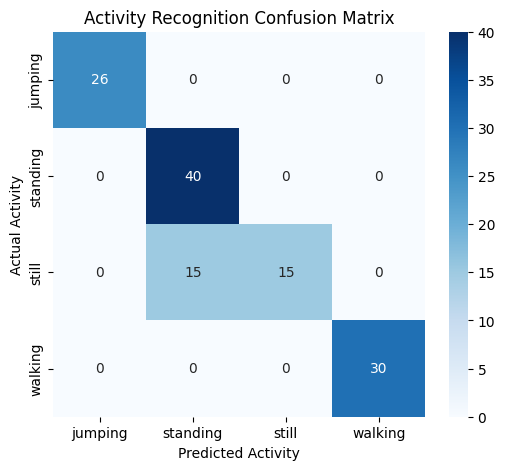

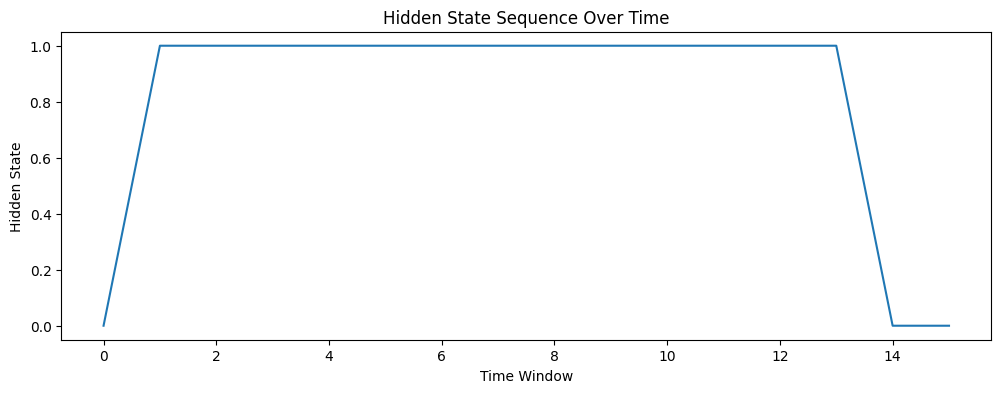

In [ ]:
# Confusion Matrix Visualization

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.title("Activity Recognition Confusion Matrix")
plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")

plt.show()

# Hidden State Sequence Timeline

# Calculate hidden states using the last trained model and the last processed test sequence
hidden_states = model.predict(X_seq)

plt.figure(figsize=(12,4))

plt.plot(hidden_states[:500])

plt.title("Hidden State Sequence Over Time")
plt.xlabel("Time Window")
plt.ylabel("Hidden State")

plt.show()